# Daphnet FoG — Segmentation & Feature Pipeline

Este notebook prepara ventanas deslizantes de características del dataset Daphnet FoG, con limpieza robusta de señales crudas (detección de outliers + interpolación polinomial) y procesamiento Leave-One-Subject-Out (LOSO) por fold para evitar fuga de datos.

Flujo del notebook (cronológico):
- Cargar dataset procesado
- Anotar etiquetas (binario + multiclase con ventana pre-FoG)
- Crear ventanas deslizantes por sujeto/trial
- Detectar e interpolar outliers en ventanas crudas
- Rellenar valores faltantes (interpolación polinomial como fallback)
- Extraer características determinísticas por ventana (tiempo, frecuencia, wavelet, no lineales)
- Pipeline LOSO por fold: limpiar, extraer features, escalar (solo en train), SMOTE (solo en train), guardar CSVs por fold

Características extraídas por ventana (lista representativa):
- Tiempo: media, std, skew, kurtosis, RMS, mediana, IQR
- Derivadas: media/std de magnitud, cadencia (conteo de picos)
- Frecuencia: pico de PSD, energía total PSD, potencias de banda (0.5-3 Hz, 3-8 Hz), índice de freezing
- Wavelet: energías wavelet, entropía wavelet
- No lineales: entropía de muestra, dimensión fractal de Higuchi

Visualizaciones: gráficos concisos en etapas clave para demostración y presentación a inversores.

In [113]:
# Imports
import sys
from pathlib import Path
import pickle
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
sns.set_style('whitegrid')
# add repo root to path if needed
sys.path.insert(0, str(Path.cwd().parent.parent))
from loaders import DaphnetDatasetLoader

# ML helpers
from sklearn.model_selection import LeaveOneGroupOut
from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer
from imblearn.over_sampling import SMOTE

# Signal tools
from scipy.signal import welch, stft, find_peaks
import scipy.stats as stats
import pywt


In [95]:
# Load processed dataset (from EDA notebook) and basic preprocessing
loader = DaphnetDatasetLoader('../../Datasets/Daphnet fog/dataset')
csv_path = '../../outputs/datasets_csv/daphnet_complete_dataset.csv'
df = loader.read_dataset(csv_path)
# Create subject/trial columns used later
df['subject'] = df['subject_id'].apply(lambda x: f'S{x:02d}')
df['trial'] = df['run_id'].apply(lambda x: f'R{x:02d}')
# Remove non-experimental rows
df = df[df['annotation'] != 0].reset_index(drop=True)
print(f'Dataset loaded: {len(df):,} samples')

📂 Cargando dataset desde: daphnet_complete_dataset.csv
✅ Dataset cargado exitosamente
   📊 Dimensiones: (1917887, 16)
   💽 Memoria: 451.50 MB
Dataset loaded: 1,140,835 samples


## Anotación de etiquetas (binario + multiclase)
Etiqueta binaria: 1 si FoG, 0 si no. Multiclase: 0=no FoG, 1=FoG, 2=pre-FoG (0.5s antes de FoG). Se detectan inicios de FoG por sujeto/trial y se asigna pre-FoG.

In [96]:
# (Recreate annotations quickly if needed)
SAMPLING_RATE = 64
PRE_FOG_WINDOW = int(0.5 * SAMPLING_RATE)
df_processed = df.copy()
df_processed['binary_label'] = (df_processed['annotation'] == 2).astype(int)
df_processed['multiclass_label'] = 0
df_processed.loc[df_processed['annotation'] == 2, 'multiclass_label'] = 1
for subject in df_processed['subject_id'].unique():
    for trial in df_processed[df_processed['subject_id'] == subject]['trial'].unique():
        mask = (df_processed['subject_id'] == subject) & (df_processed['trial'] == trial)
        indices = df_processed[mask].index
        fog_labels = df_processed.loc[indices, 'annotation'].values
        fog_starts = []
        for i in range(1, len(fog_labels)):
            if fog_labels[i] == 2 and fog_labels[i-1] != 2:
                fog_starts.append(i)
        for start_idx in fog_starts:
            pre_fog_start = max(0, start_idx - PRE_FOG_WINDOW)
            pre_fog_indices = indices[pre_fog_start:start_idx]
            df_processed.loc[pre_fog_indices[df_processed.loc[pre_fog_indices, 'multiclass_label'] == 0], 'multiclass_label'] = 2
from IPython.display import display
# show label distribution succinctly
display(df_processed['multiclass_label'].value_counts().sort_index())

multiclass_label
0    1022466
1     110785
2       7584
Name: count, dtype: int64

## Ventanas deslizantes (mantienen continuidad temporal por sujeto/trial)
Funciones para crear ventanas deslizantes de 4s con 50% solapamiento. Se crean por sujeto/trial para evitar cruzar límites de trial. Etiqueta de ventana = moda de etiquetas en la ventana.

In [97]:
def create_sliding_windows(data, labels, window_size, overlap=0.5, sampling_rate=64):
    window_samples = int(window_size * sampling_rate)
    step_size = int(window_samples * (1 - overlap))
    windows, window_labels = [], []
    for start in range(0, len(data) - window_samples + 1, step_size):
        end = start + window_samples
        window = data[start:end]
        window_label_segment = labels[start:end]
        window_label = np.bincount(window_label_segment).argmax()
        windows.append(window)
        window_labels.append(window_label)
    return np.array(windows), np.array(window_labels)

def create_windows_per_subject(df_subset, feature_cols, label_col, window_size, overlap=0.5):
    all_windows, all_labels, all_subjects = [], [], []
    for subject in df_subset['subject'].unique():
        for trial in df_subset[df_subset['subject'] == subject]['trial'].unique():
            mask = (df_subset['subject'] == subject) & (df_subset['trial'] == trial)
            subject_data = df_subset[mask]
            X_subject = subject_data[feature_cols].values
            y_subject = subject_data[label_col].values
            windows, labels = create_sliding_windows(X_subject, y_subject, window_size, overlap)
            if len(windows) > 0:
                all_windows.append(windows)
                all_labels.append(labels)
                all_subjects.extend([subject] * len(windows))
    if len(all_windows) > 0:
        all_windows = np.concatenate(all_windows, axis=0)
        all_labels = np.concatenate(all_labels, axis=0)
        all_subjects = np.array(all_subjects)
    else:
        all_windows = np.array([])
        all_labels = np.array([])
        all_subjects = np.array([])
    return all_windows, all_labels, all_subjects

# Sliding-window helper functions defined

In [98]:
# Create LOSO sample-level splits and sliding windows (call the functions)
feature_columns = [col for col in df_processed.columns if any(sensor in col for sensor in ['ankle','thigh','trunk'])]
X = df_processed[feature_columns].values
y_multiclass = df_processed['multiclass_label'].values
groups = df_processed['subject'].values

logo = LeaveOneGroupOut()
loso_splits = []

for fold,(train_idx,test_idx) in enumerate(logo.split(X,y_multiclass,groups)):
    test_subject = groups[test_idx][0]
    loso_splits.append({'fold':fold,'test_subject':test_subject,'train_idx':train_idx,'test_idx':test_idx})

print(f'Created LOSO sample-level splits: {len(loso_splits)} folds')

# Create windows per fold (4s windows, 50% overlap)

WINDOW_SIZE_SEC = 4
OVERLAP = 0.5
SAMPLING_RATE = 64

loso_window_splits_binary = []
loso_window_splits_multiclass = []

for fold in loso_splits:
    df_train = df_processed.iloc[fold['train_idx']].reset_index(drop=True)
    df_test = df_processed.iloc[fold['test_idx']].reset_index(drop=True)
    X_train_win_bin, y_train_win_bin, subj_train_bin = create_windows_per_subject(df_train, feature_columns, 'binary_label', WINDOW_SIZE_SEC, OVERLAP)
    X_test_win_bin, y_test_win_bin, subj_test_bin = create_windows_per_subject(df_test, feature_columns, 'binary_label', WINDOW_SIZE_SEC, OVERLAP)
    X_train_win_multi, y_train_win_multi, subj_train_multi = create_windows_per_subject(df_train, feature_columns, 'multiclass_label', WINDOW_SIZE_SEC, OVERLAP)
    X_test_win_multi, y_test_win_multi, subj_test_multi = create_windows_per_subject(df_test, feature_columns, 'multiclass_label', WINDOW_SIZE_SEC, OVERLAP)

    loso_window_splits_binary.append({
        'fold': fold['fold'], 'test_subject': fold['test_subject'],
        'X_train': X_train_win_bin, 'X_test': X_test_win_bin,
        'y_train': y_train_win_bin, 'y_test': y_test_win_bin,
        'subjects_train': subj_train_bin, 'subjects_test': subj_test_bin,
        'train_dist': np.bincount(y_train_win_bin, minlength=2), 'test_dist': np.bincount(y_test_win_bin, minlength=2)
    })

    loso_window_splits_multiclass.append({
        'fold': fold['fold'], 'test_subject': fold['test_subject'],
        'X_train': X_train_win_multi, 'X_test': X_test_win_multi,
        'y_train': y_train_win_multi, 'y_test': y_test_win_multi,
        'subjects_train': subj_train_multi, 'subjects_test': subj_test_multi,
        'train_dist': np.bincount(y_train_win_multi, minlength=3), 'test_dist': np.bincount(y_test_win_multi, minlength=3)
    })

Created LOSO sample-level splits: 10 folds


C:\Users\david\AppData\Local\Temp\ipykernel_43528\3049624766.py:18: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=list(subs), y=list(vals), palette='viridis')


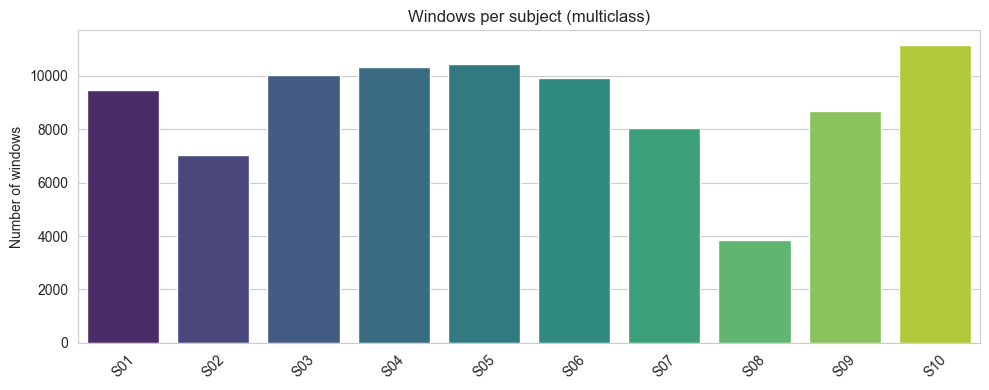

In [102]:
# Windows per-subject summary (visualization)
from collections import Counter
def plot_windows_per_subject(splits_list, title='Windows per subject (multiclass)'):
    if not splits_list:
        print('No window splits available to plot.')
        return
    counts = Counter()
    for d in splits_list:
        for arr_key in ('subjects_train','subjects_test'):
            arr = d.get(arr_key, None)
            if arr is None or len(arr)==0:
                continue
            for s in arr:
                counts[s] += 1
    items = sorted(counts.items(), key=lambda x: x[0])
    subs, vals = zip(*items) if items else ([],[])
    plt.figure(figsize=(10,4))
    sns.barplot(x=list(subs), y=list(vals), palette='viridis')
    plt.xticks(rotation=45)
    plt.ylabel('Number of windows')
    plt.title(title)
    plt.tight_layout()
    plt.show()

# call for multiclass then binary (if available)
if 'loso_window_splits_multiclass' in globals() and loso_window_splits_multiclass:
    plot_windows_per_subject(loso_window_splits_multiclass, title='Windows per subject (multiclass)')
elif 'loso_window_splits_binary' in globals() and loso_window_splits_binary:
    plot_windows_per_subject(loso_window_splits_binary, title='Windows per subject (binary)')

## Interpolación de outliers
Detecta outliers por canal usando MAD (Median Absolute Deviation): si |x - mediana| > 3 * MAD, es outlier. Se interpola con polinomio de grado 3 sobre puntos buenos; fallback a lineal o mediana.

In [99]:
def interpolate_outliers_in_windows(windows, poly_order=3, thresh_mul=3.0):
    """Detect outliers per channel (MAD) and interpolate them using a polynomial fit."""
    w = np.array(windows, dtype=float).copy()
    if w.size == 0:
        return w
    n_win, n_samp, n_ch = w.shape
    for i in range(n_win):
        for ch in range(n_ch):
            x = w[i, :, ch]
            med = np.median(x)
            mad = np.median(np.abs(x - med))
            if mad == 0 or np.isnan(mad):
                mad = np.std(x) if np.std(x) > 0 else 1.0
            thresh = thresh_mul * 1.4826 * mad
            mask = np.abs(x - med) > thresh
            if not np.any(mask):
                continue
            idx = np.arange(n_samp)
            good = idx[~mask]
            bad = idx[mask]
            if good.size >= 2:
                deg = min(poly_order, good.size - 1)
                try:
                    coeffs = np.polyfit(good, x[good], deg)
                    x[bad] = np.polyval(coeffs, bad)
                except Exception:
                    if good.size >= 2:
                        x[bad] = np.interp(bad, good, x[good])
                    else:
                        x[bad] = med
            else:
                x[mask] = med
            w[i, :, ch] = x
    return w


In [100]:
# Visualize outliers for an example window (first available)
def plot_outliers_in_window(window, poly_order=3, thresh_mul=3.0, ax=None):
    n_samp, n_ch = window.shape
    med = np.median(window, axis=0)
    mad = np.median(np.abs(window - med), axis=0)
    mad = np.where((mad == 0) | np.isnan(mad), np.std(window, axis=0), mad)
    thresh = thresh_mul * 1.4826 * mad
    idx = np.arange(n_samp)
    fig, axes = plt.subplots(n_ch, 1, figsize=(12, 2*n_ch), sharex=True)
    if n_ch == 1:
        axes = [axes]
    for ch in range(n_ch):
        x = window[:, ch]
        mask = np.abs(x - med[ch]) > thresh[ch]
        axes[ch].plot(idx, x, label=f'channel {ch}')
        axes[ch].scatter(idx[mask], x[mask], color='red', s=20, label='outlier')
        axes[ch].axhline(med[ch], color='k', linestyle='--', alpha=0.4)
        axes[ch].set_ylabel(f'ch{ch}')
        axes[ch].legend(loc='upper right')
    axes[-1].set_xlabel('sample')
    plt.tight_layout()
    return fig, axes



Plotting outliers for the first example window


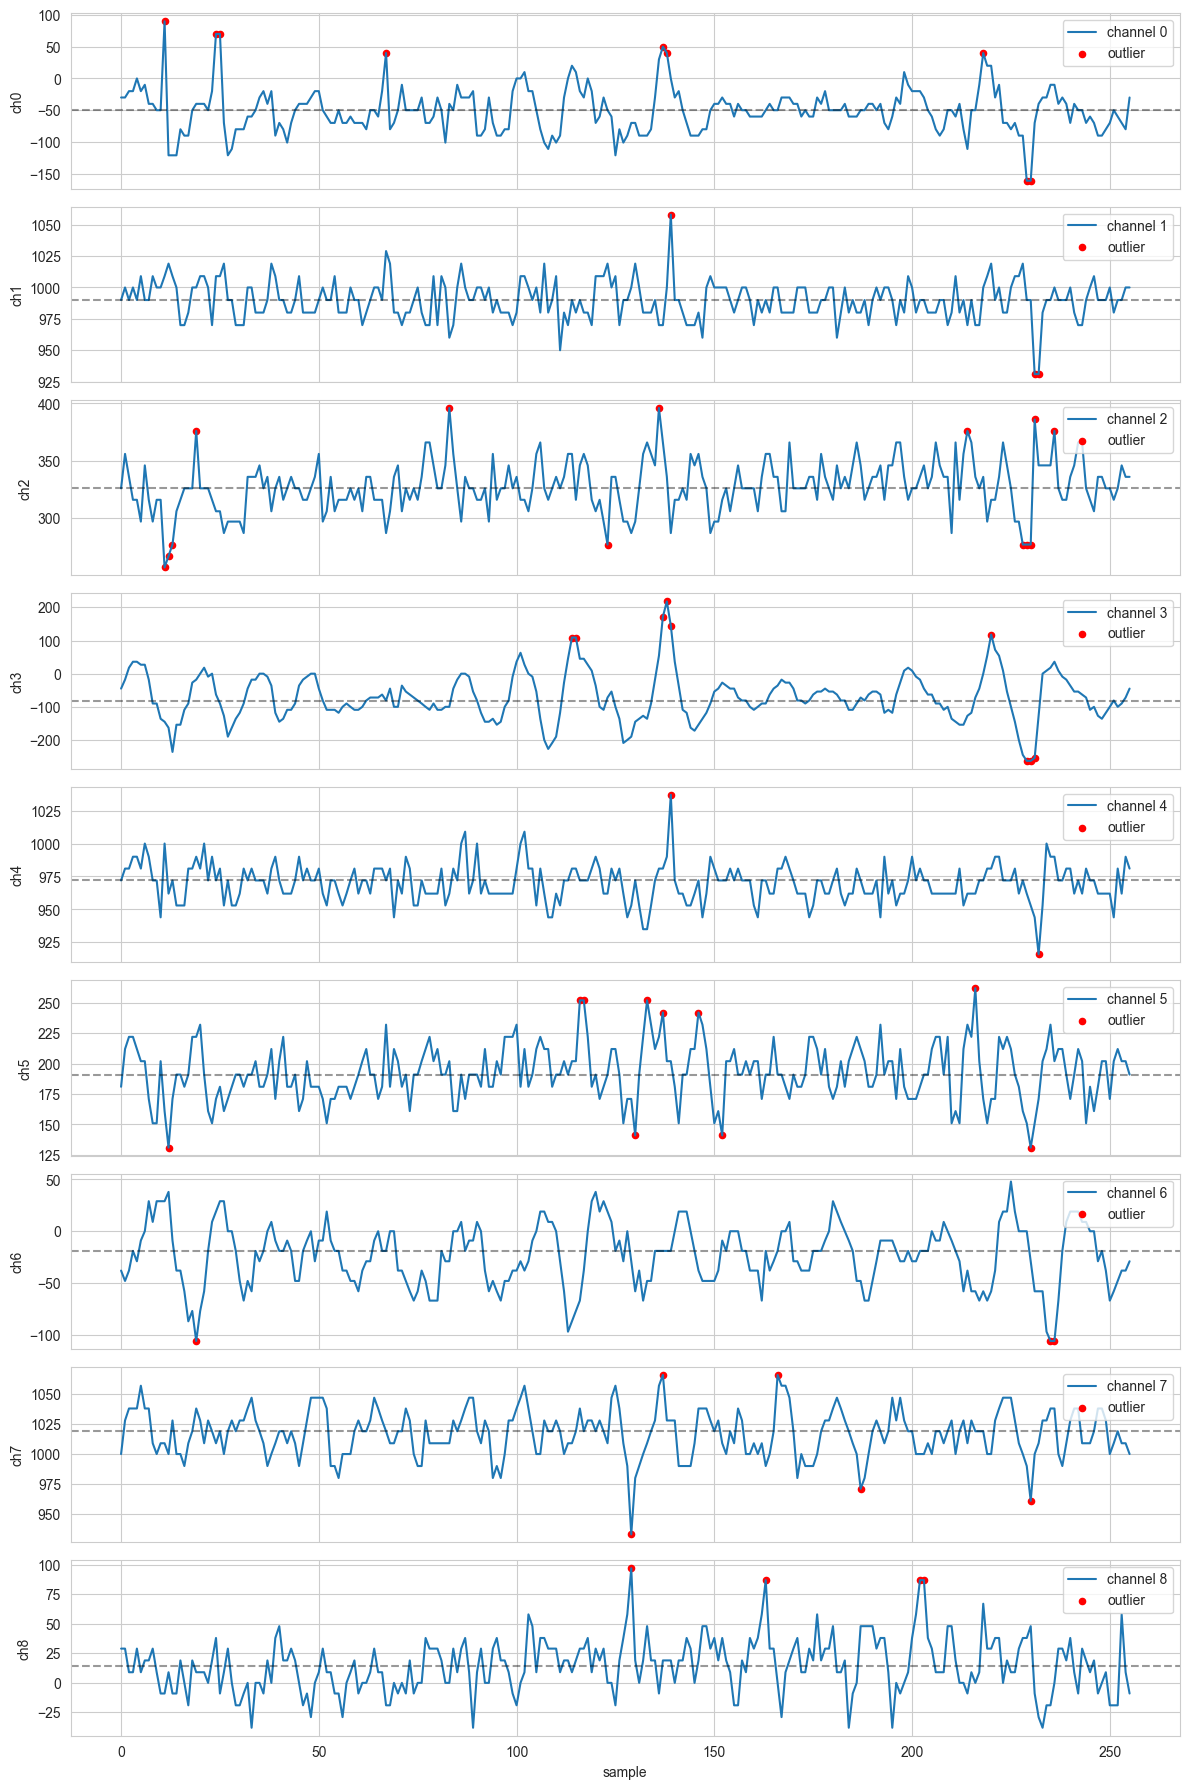

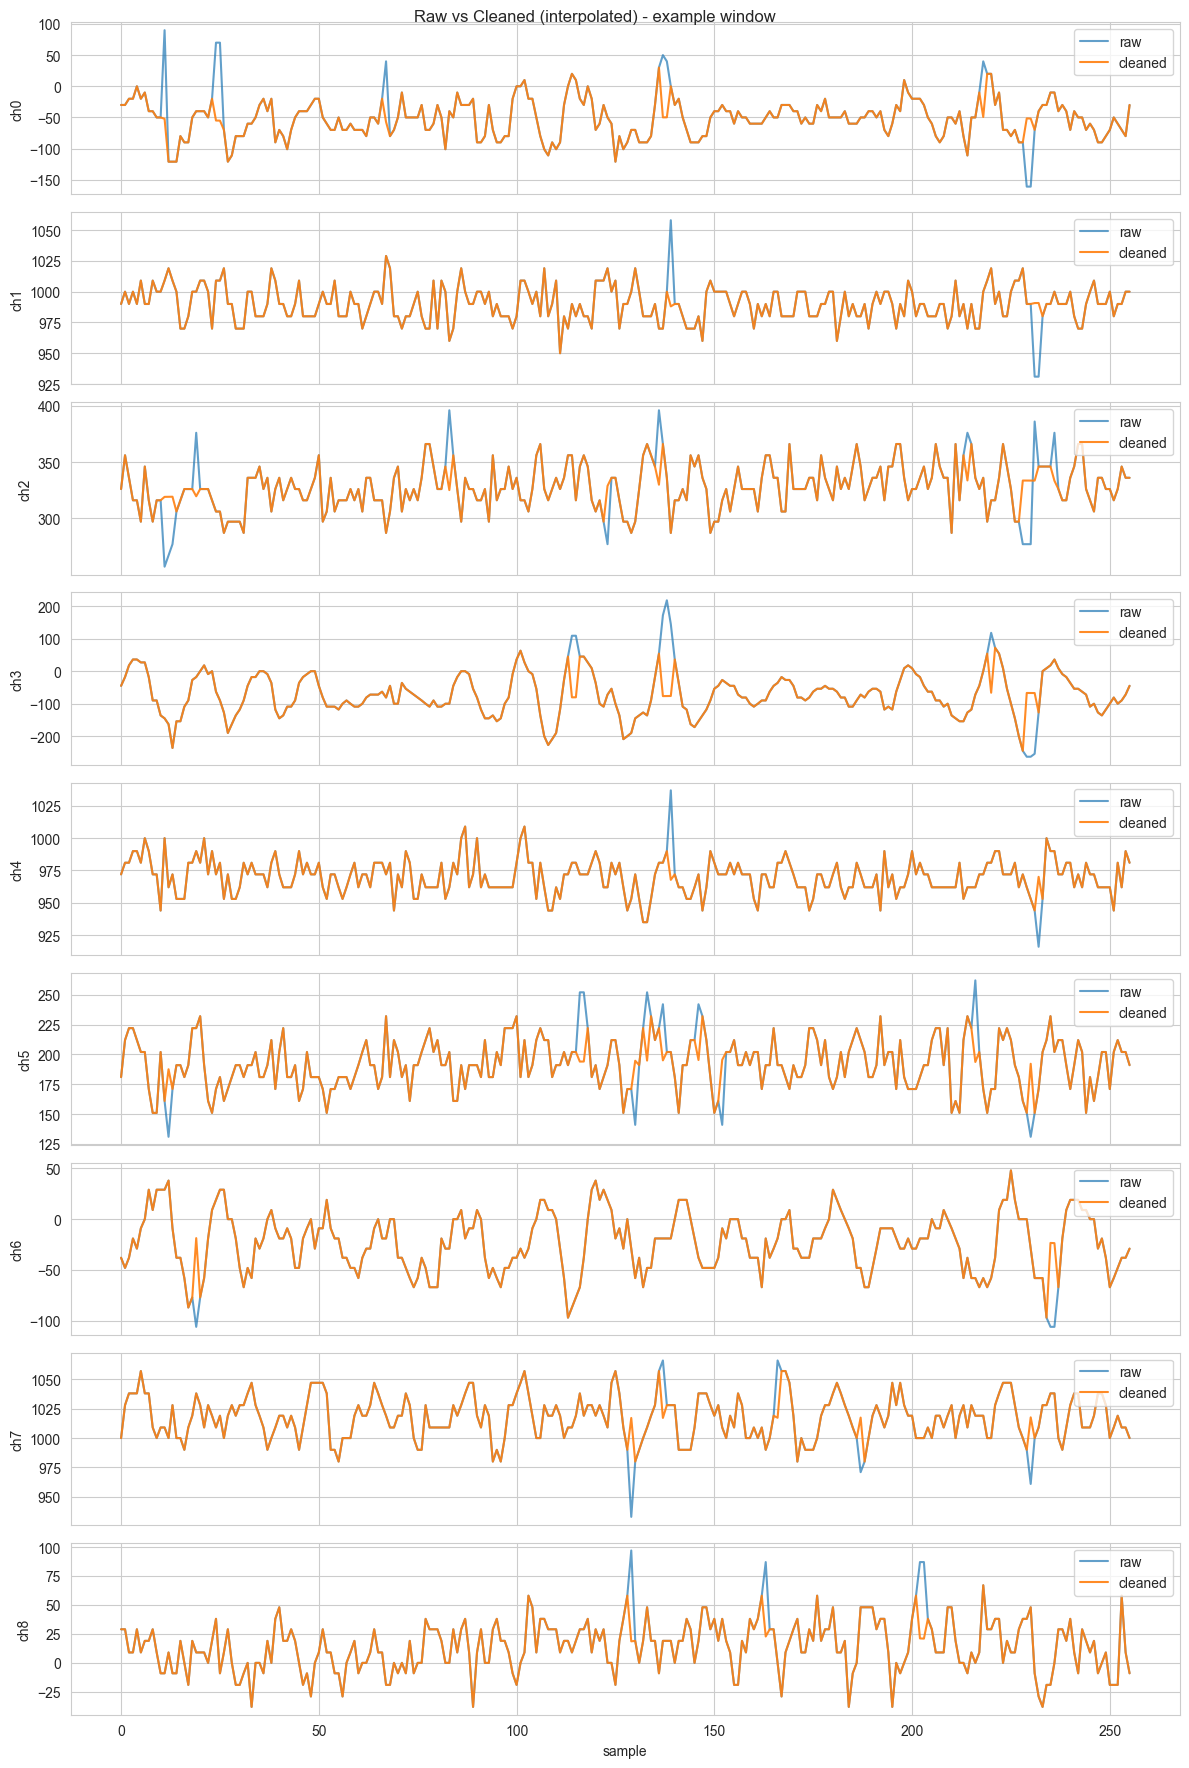

In [101]:
# Attempt to get an example window and plot raw vs cleaned (call interpolation)
example_window = None

def _try_load(path):
    p = Path(path)
    if p.exists():
        try:
            with open(p, 'rb') as f:
                return pickle.load(f)
        except Exception as e:
            print(f'Warning: failed to load {p}: {e}')
    return None

# Priority: in-memory multiclass -> in-memory binary -> multiclass pickle -> binary pickle
splits = None
if 'loso_window_splits_multiclass' in globals():
    splits = loso_window_splits_multiclass
elif 'loso_window_splits_binary' in globals():
    splits = loso_window_splits_binary
else:
    splits = _try_load('../../outputs/datasets_csv/daphnet_loso_windows_multiclass.pkl')
    if splits is None:
        splits = _try_load('../../outputs/datasets_csv/daphnet_loso_windows_binary.pkl')

if splits is not None and isinstance(splits, list) and len(splits) > 0:
    first = splits[0]
    if isinstance(first, dict) and 'X_test' in first and len(first['X_test']) > 0:
        example_window = first['X_test'][0]

if example_window is None:
    print('No example window available to plot outliers. Run window-creation cells or provide the LOSO pickle files.')
else:
    print('Plotting outliers for the first example window')
    plot_outliers_in_window(example_window)
    plt.show()

# Also compute cleaned version and plot before/after per channel
if example_window is not None:
    cleaned = interpolate_outliers_in_windows(np.expand_dims(example_window,0))[0]
    n_ch = example_window.shape[1]
    fig, axes = plt.subplots(n_ch, 1, figsize=(12, 2*n_ch), sharex=True)
    if n_ch == 1:
        axes = [axes]
    for ch in range(n_ch):
        axes[ch].plot(example_window[:, ch], label='raw', alpha=0.7)
        axes[ch].plot(cleaned[:, ch], label='cleaned', alpha=0.9)
        axes[ch].set_ylabel(f'ch{ch}')
        axes[ch].legend(loc='upper right')
    axes[-1].set_xlabel('sample')
    plt.suptitle('Raw vs Cleaned (interpolated) - example window')
    plt.tight_layout()
    plt.show()

### Valores faltantes
Se detectan NaNs por canal en ventanas, se rellenan con interpolación polinomial sobre puntos válidos; fallback a lineal o mediana.

## Missing values

Tratamiento: se detectan NaNs por canal y se rellenan con un ajuste polinómico sobre los puntos válidos. Si no hay suficientes puntos válidos, se usa interpolación lineal o la mediana como fallback.

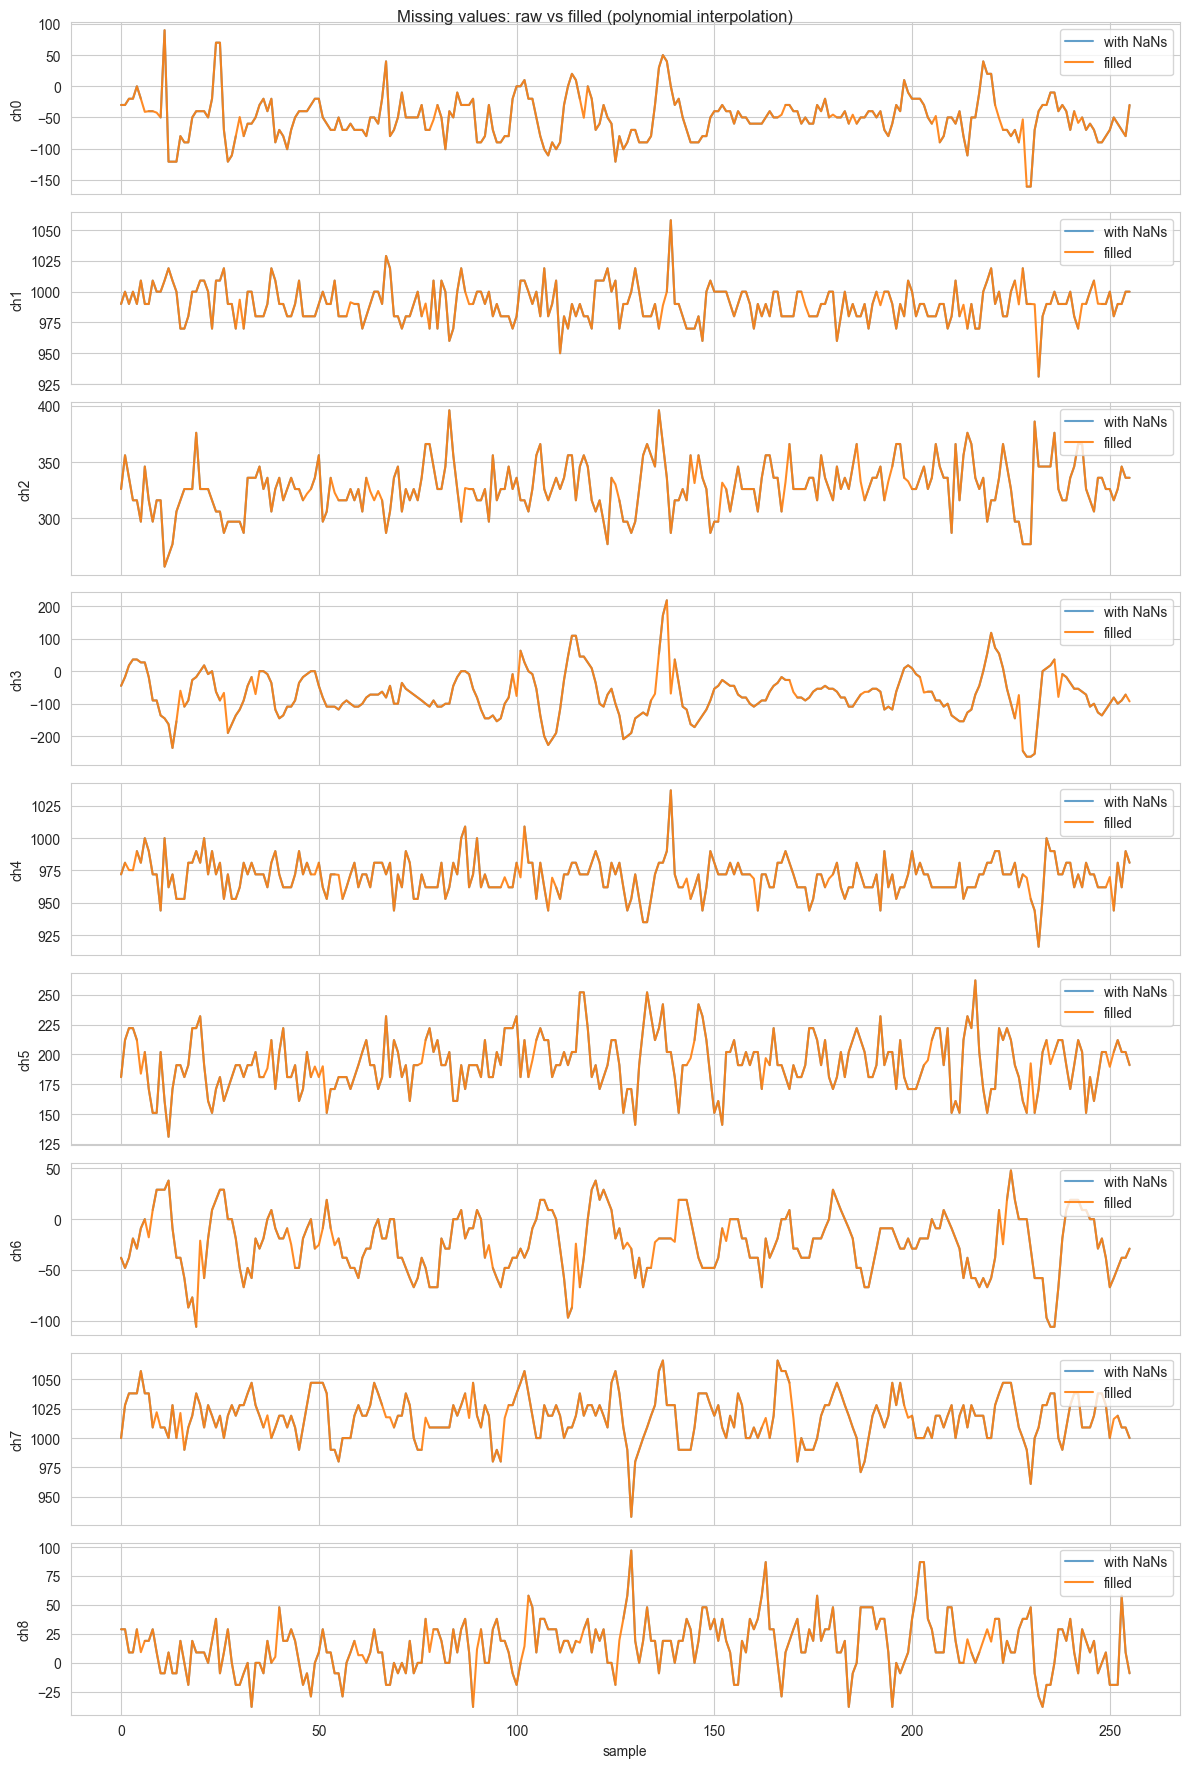

In [103]:
# Missing values section: polynomial interpolation per-channel and per-window
from IPython.display import Markdown, display
display(Markdown('## Missing values\n\nTratamiento: se detectan NaNs por canal y se rellenan con un ajuste polinómico sobre los puntos válidos. Si no hay suficientes puntos válidos, se usa interpolación lineal o la mediana como fallback.'))

def interpolate_missing_values_in_windows(windows, poly_order=3):
    w = np.array(windows, dtype=float).copy()
    if w.size == 0:
        return w
    n_win, n_samp, n_ch = w.shape
    for i in range(n_win):
        for ch in range(n_ch):
            x = w[i, :, ch]
            mask_nan = np.isnan(x)
            if not np.any(mask_nan):
                continue
            idx = np.arange(n_samp)
            good = idx[~mask_nan]
            bad = idx[mask_nan]
            if good.size >= 2:
                deg = min(poly_order, good.size - 1)
                try:
                    coeffs = np.polyfit(good, x[good], deg)
                    x[bad] = np.polyval(coeffs, bad)
                except Exception:
                    try:
                        x[bad] = np.interp(bad, good, x[good])
                    except Exception:
                        x[bad] = np.nanmedian(x[good]) if good.size>0 else 0.0
            elif good.size == 1:
                x[bad] = x[good[0]]
            else:
                x[mask_nan] = 0.0
            w[i, :, ch] = x
    return w

# Demonstration: if example_window exists, introduce some NaNs artificially (if none present) and show before/after
try:
    example_window  # check existence
except NameError:
    example_window = None
if example_window is None:
    display(Markdown('**No example window available to demonstrate missing-value interpolation.** Run window creation cells to produce demo windows.'))
else:
    # ensure float dtype to allow NaNs
    demo = example_window.astype(float).copy()
    # introduce NaNs at random positions to demonstrate (only if no NaNs present already)
    if not np.any(np.isnan(demo)):
        rng = np.random.RandomState(42)
        n_samp = demo.shape[0]
        for ch in range(demo.shape[1]):
            nan_idx = rng.choice(n_samp, size=max(1, n_samp//20), replace=False)
            demo[nan_idx, ch] = np.nan
    # showing raw (with NaNs) vs after polynomial interpolation
    filled = interpolate_missing_values_in_windows(np.expand_dims(demo,0))[0]
    n_ch = demo.shape[1]
    fig, axes = plt.subplots(n_ch, 1, figsize=(12, 2*n_ch), sharex=True)
    if n_ch == 1:
        axes = [axes]
    for ch in range(n_ch):
        axes[ch].plot(demo[:, ch], label='with NaNs', alpha=0.7)
        axes[ch].plot(filled[:, ch], label='filled', alpha=0.9)
        axes[ch].set_ylabel(f'ch{ch}')
        axes[ch].legend(loc='upper right')
    axes[-1].set_xlabel('sample')
    plt.suptitle('Missing values: raw vs filled (polynomial interpolation)')
    plt.tight_layout()
    plt.show()

In [108]:
df.isna().sum()

time_ms               0
ankle_acc_forward     0
ankle_acc_vertical    0
ankle_acc_lateral     0
thigh_acc_forward     0
thigh_acc_vertical    0
thigh_acc_lateral     0
trunk_acc_forward     0
trunk_acc_vertical    0
trunk_acc_lateral     0
annotation            0
subject_id            0
run_id                0
filename              0
annotation_label      0
time_s                0
subject               0
trial                 0
dtype: int64

## Extracción de características (determinísticas por ventana)
Extrae features multi-dominio: tiempo (estadísticas básicas), frecuencia (PSD, bandas), wavelet (energías, entropía), no lineales (entropía de muestra, Higuchi FD). Usa trapezoidal robusto para integrales.

In [109]:
# Small helpers
def RMS(x):
    return np.sqrt(np.mean(x**2))

def _trapz(y, x):
    # Prefer numpy.trapezoid (newer NumPy) then numpy.trapz, fallback to manual implementation
    try:
        if hasattr(np, 'trapezoid'):
            return np.trapezoid(y, x)
        if hasattr(np, 'trapz'):
            return np.trapz(y, x)
    except Exception:
        pass
    y = np.asarray(y)
    x = np.asarray(x)
    if y.size == 0 or x.size == 0:
        return 0.0
    if y.size != x.size:
        return 0.0
    if y.size == 1:
        return 0.0
    return 0.5 * np.sum((y[:-1] + y[1:]) * (x[1:] - x[:-1]))

def sample_entropy(time_series, m=2, r=None):
    x = np.array(time_series)
    N = len(x)
    if N <= m+1:
        return np.nan
    if r is None:
        r = 0.2 * np.std(x)
    def _phi(m):
        xmi = np.array([x[i:i+m] for i in range(N - m + 1)])
        C = 0
        for i in range(len(xmi)):
            d = np.max(np.abs(xmi - xmi[i]), axis=1)
            C += np.sum(d <= r) - 1
        denom = (N - m + 1) * (N - m)
        return C / denom if denom>0 else 0
    try:
        val = -np.log(_phi(m+1) / _phi(m))
        return val
    except Exception:
        return np.nan

def higuchi_fd(x, kmax=10):
    x = np.asarray(x)
    N = x.size
    if N < 4:
        return np.nan
    L = []
    for k in range(1, kmax+1):
        Lk = 0.0
        for m in range(k):
            idx = np.arange(m, N, k)
            if idx.size < 2:
                continue
            Lm = np.sum(np.abs(np.diff(x[idx]))) * (N - 1) / ((idx.size - 1) * k)
            Lk += Lm
        L.append(Lk / k)
    L = np.array(L)
    ik = np.arange(1, len(L)+1)
    try:
        coeffs = np.polyfit(np.log(ik), np.log(L), 1)
        return coeffs[0]
    except Exception:
        return np.nan

def extract_features_window(window, sr=SAMPLING_RATE):
    feats = {}
    mag = np.linalg.norm(window, axis=1)
    signals = {'mag': mag}
    for ch in range(window.shape[1]):
        signals[f'ch{ch}'] = window[:, ch]
    for name, sig in signals.items():
        feats[f'{name}_mean'] = np.mean(sig)
        feats[f'{name}_std'] = np.std(sig)
        feats[f'{name}_skew'] = stats.skew(sig)
        feats[f'{name}_kurt'] = stats.kurtosis(sig)
        feats[f'{name}_rms'] = RMS(sig)
        feats[f'{name}_median'] = np.median(sig)
        feats[f'{name}_iqr'] = np.subtract(*np.percentile(sig, [75,25]))
    peaks, _ = find_peaks(mag, distance=sr*0.3)
    steps = len(peaks)
    duration_min = len(mag) / sr / 60.0
    feats['cadence'] = steps / duration_min if duration_min>0 else 0.0
    f, Pxx = welch(mag, fs=sr, nperseg=min(256, len(mag)))
    feats['psd_peak_freq'] = f[np.argmax(Pxx)] if Pxx.size>0 else np.nan
    feats['psd_total_energy'] = _trapz(Pxx, f) if Pxx.size>0 else 0.0
    def band_power(fv, P, low, high):
        mask = (fv>=low)&(fv<=high)
        return _trapz(P[mask], fv[mask]) if np.any(mask) else 0.0
    P_freeze = band_power(f, Pxx, 3.0, 8.0)
    P_loco = band_power(f, Pxx, 0.5, 3.0)
    feats['freezing_index'] = P_freeze / P_loco if P_loco>0 else np.inf
    try:
        coeffs = pywt.wavedec(mag, 'db4', level=3)
        for i, c in enumerate(coeffs):
            feats[f'wavelet_energy_{i}'] = np.sum(np.array(c)**2)
        W = np.concatenate([np.abs(c) for c in coeffs])
        P = W / np.sum(W) if np.sum(W)>0 else np.zeros_like(W)
        feats['wavelet_entropy'] = -np.sum(P * np.log(P + 1e-12))
    except Exception:
        feats['wavelet_entropy'] = np.nan
        for i in range(4):
            feats[f'wavelet_energy_{i}'] = np.nan
    try:
        f_stft, t_stft, Z = stft(mag, fs=sr, nperseg=min(128, len(mag)))
        S = np.abs(Z)
        if S.size>0:
            centroid = np.sum((f_stft[:,None]*S), axis=0) / (np.sum(S, axis=0)+1e-12)
            feats['stft_centroid_mean'] = np.mean(centroid)
        else:
            feats['stft_centroid_mean'] = np.nan
    except Exception:
        feats['stft_centroid_mean'] = np.nan
    feats['sampen'] = sample_entropy(mag)
    feats['higuchi_fd'] = higuchi_fd(mag)
    feats['lyap_exp'] = np.nan
    return feats

def extract_feature_matrix(windows, sr=SAMPLING_RATE):
    records = []
    for w in windows:
        records.append(extract_features_window(w, sr=sr))
    return pd.DataFrame(records)


Feature matrix head (fold 0 test):


,mag_mean,mag_std,mag_skew,mag_kurt,mag_rms,mag_median,mag_iqr,ch0_mean,ch0_std,ch0_skew,...,freezing_index,wavelet_energy_0,wavelet_energy_1,wavelet_energy_2,wavelet_energy_3,wavelet_entropy,stft_centroid_mean,sampen,higuchi_fd,lyap_exp
0,1765.581908,16.295881,0.122408,-0.328312,1765.657110,1765.464631,21.867611,-52.323943,28.401825,0.061127,...,7.761295,9.498596e+08,17517.371332,18330.848389,16551.512284,3.734246,2.508212,2.194277,-0.858343,NaN
1,1765.333306,17.440759,-0.081787,-0.291982,1765.419458,1766.352315,24.049723,-55.092055,26.086348,0.210344,...,11.191490,9.457609e+08,26602.780251,23751.639063,16380.614944,3.739379,2.516321,1.990500,-0.867375,NaN
2,1765.731071,20.589327,-0.098335,-0.230337,1765.851107,1766.565002,28.107454,-64.294008,26.846900,0.146310,...,12.284375,9.494791e+08,43104.578972,32214.598150,14687.499824,3.749963,2.551176,1.935836,-0.828694,NaN
3,1765.335182,21.146155,-0.102549,-0.101638,1765.461827,1765.785094,27.782404,-73.336339,28.320949,0.045111,...,56.804834,9.497749e+08,51221.706058,33923.378907,12851.865393,3.746171,2.527680,1.820463,-0.794912,NaN
4,1767.035248,23.685024,0.215349,0.352096,1767.193975,1766.932936,34.205741,-82.704805,32.477636,0.041839,...,7.712922,9.523365e+08,58111.890937,44801.995616,22234.085185,3.764424,2.589490,1.949251,-0.827717,NaN


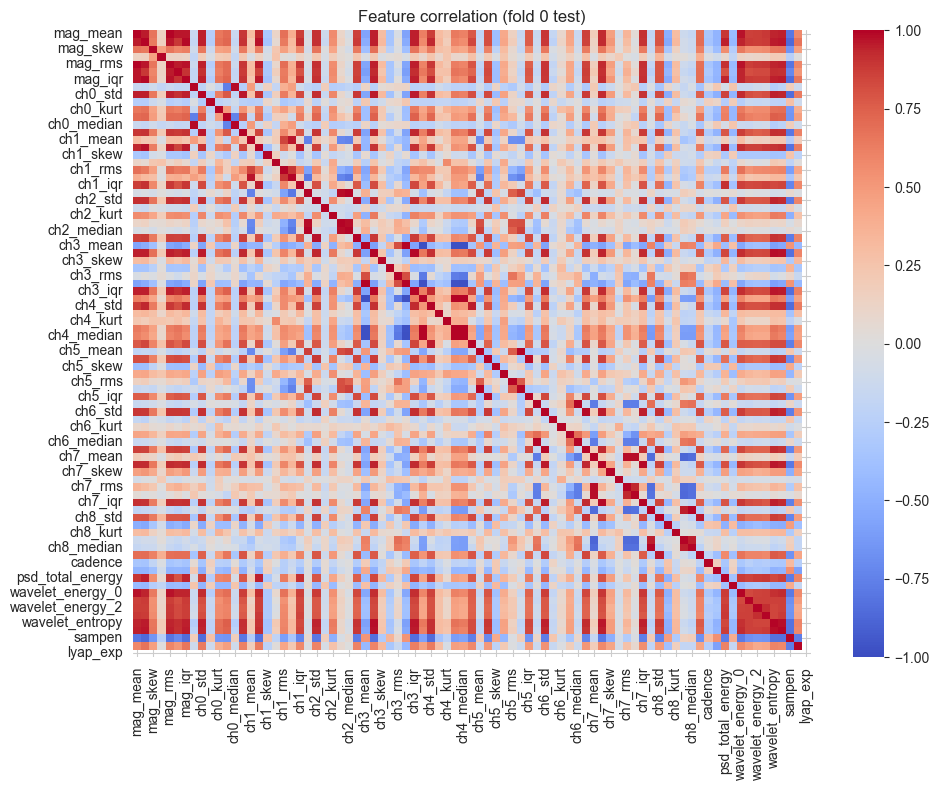

In [110]:
# Example: extract features for first fold test set and show correlation heatmap (calls feature extraction)
if 'loso_window_splits_multiclass' in globals() and len(loso_window_splits_multiclass)>0:
    fold0 = loso_window_splits_multiclass[0]
    if len(fold0['X_test'])>0:
        X_test = fold0['X_test']
        X_test_clean = interpolate_outliers_in_windows(X_test)
        feats = extract_feature_matrix(X_test_clean)
        print('Feature matrix head (fold 0 test):')
        display(feats.head())
        plt.figure(figsize=(10,8))
        sns.heatmap(feats.corr(), vmin=-1, vmax=1, cmap='coolwarm')
        plt.title('Feature correlation (fold 0 test)')
        plt.tight_layout()
        plt.show()
    else:
        print('Fold 0 test has no windows')
else:
    print('No LOSO window splits available in memory — run window creation cell or load pickles.')

Plotting feature comparison for example window


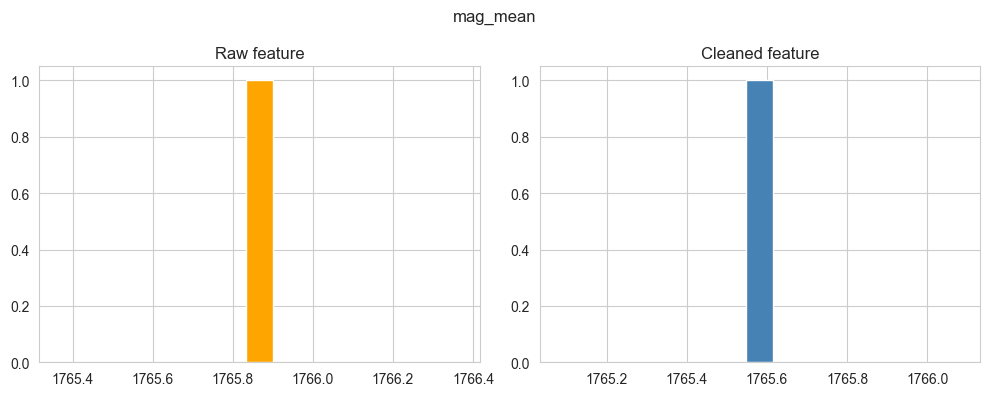

In [106]:
# Feature extraction visualization: compare distribution of a feature before/after cleaning for a few windows
def compare_feature_before_after(raw_window, cleaned_window, feature_name='mag_mean'):
    raw_feat = extract_features_window(raw_window)[feature_name]
    clean_feat = extract_features_window(cleaned_window)[feature_name]
    fig, ax = plt.subplots(1,2, figsize=(10,4))
    ax[0].hist(raw_feat if np.ndim(raw_feat)>0 else [raw_feat], bins=15, color='orange')
    ax[0].set_title('Raw feature')
    ax[1].hist(clean_feat if np.ndim(clean_feat)>0 else [clean_feat], bins=15, color='steelblue')
    ax[1].set_title('Cleaned feature')
    plt.suptitle(feature_name)
    plt.tight_layout()
    return fig

# Try to get a raw example and cleaned example (if available)
if 'loso_window_splits_multiclass' in globals():
    fold = loso_window_splits_multiclass[0]
    if len(fold['X_test'])>0:
        raw = fold['X_test'][0]
        cleaned = interpolate_outliers_in_windows(np.expand_dims(raw,0))[0]
        print('Plotting feature comparison for example window')
        compare_feature_before_after(raw, cleaned, feature_name='mag_mean')
        plt.show()
else:
    print('No windows available in memory — run window creation cells first or load pickles.')

## Pipeline LOSO por fold (evita fuga de datos)
Por cada fold: limpia outliers/NaNs en ventanas, extrae features, escala (fit solo en train), SMOTE (solo en train), guarda CSVs por fold. Todo separado por fold para no contaminar test.

In [117]:
# Robust imputation, scaling, SMOTE and per-fold saving
from IPython.display import display, Markdown

# Ensure FEATURE_OUTPUT exists
try:
    FEATURE_OUTPUT
except NameError:
    FEATURE_OUTPUT = Path('../../outputs/daphnet_features')
    FEATURE_OUTPUT.mkdir(parents=True, exist_ok=True)


def _coerce_numeric_df(df):
    """Coerce all columns of a DataFrame to numeric, turning non-numeric to NaN."""
    if df is None:
        return pd.DataFrame()
    df_num = df.copy()
    for c in df_num.columns:
        df_num[c] = pd.to_numeric(df_num[c], errors='coerce')
    return df_num


def handle_missing_and_scale(X_train_feats, X_test_feats):
    """Replace infs, coerce to numeric, median-impute (fit on train), and StandardScale.

    Returns: X_train_scaled, X_test_scaled, X_train_imp_df, X_test_imp_df, imputer, scaler
    """
    # Defensive defaults
    if X_train_feats is None:
        X_train_feats = pd.DataFrame()
    if X_test_feats is None:
        X_test_feats = pd.DataFrame()

    # Replace infs
    X_train = X_train_feats.replace([np.inf, -np.inf], np.nan).copy()
    X_test = X_test_feats.replace([np.inf, -np.inf], np.nan).copy()

    # Coerce to numeric (non-numeric -> NaN)
    X_train_num = _coerce_numeric_df(X_train)
    X_test_num = _coerce_numeric_df(X_test)

    print('handle_missing_and_scale: X_train shape:', X_train_num.shape)

    # Fit imputer on train only
    imp = SimpleImputer(strategy='median')
    try:
        arr_train = imp.fit_transform(X_train_num)
    except Exception as e:
        print('Imputer.fit_transform failed on full train features:', e)
        X_train_num = X_train_num.select_dtypes(include=[np.number])
        arr_train = imp.fit_transform(X_train_num)

    # Build column names aligned with imputer output
    n_train_cols = arr_train.shape[1]
    train_cols = list(X_train_num.columns)
    if len(train_cols) != n_train_cols:
        print(f'Warning: imputer returned {n_train_cols} cols but train had {len(train_cols)} cols. Adjusting column names.')
        if n_train_cols < len(train_cols):
            res_train_cols = train_cols[:n_train_cols]
        else:
            res_train_cols = train_cols + [f'extra_imp_col_{i}' for i in range(len(train_cols), n_train_cols)]
    else:
        res_train_cols = train_cols

    X_train_imp = pd.DataFrame(arr_train, columns=res_train_cols)

    # Transform test (reindex to train cols to preserve order)
    try:
        arr_test = imp.transform(X_test_num.reindex(columns=X_train_num.columns, fill_value=np.nan))
    except Exception as e:
        print('Imputer.transform failed on test features:', e)
        arr_test = imp.transform(X_test_num.reindex(columns=X_train_num.columns, fill_value=np.nan))

    # Ensure test has same number of columns as train
    if arr_test.shape[1] != arr_train.shape[1]:
        print('Warning: transformed test shape differs from train; adjusting.')
        if arr_test.shape[1] < arr_train.shape[1]:
            pad = np.full((arr_test.shape[0], arr_train.shape[1] - arr_test.shape[1]), np.nan)
            arr_test = np.hstack([arr_test, pad])
        else:
            arr_test = arr_test[:, :arr_train.shape[1]]

    X_test_imp = pd.DataFrame(arr_test, columns=res_train_cols)

    # Report NaNs after imputation (sanity)
    nan_after = X_train_imp.isnull().sum()
    if nan_after.sum() > 0:
        print('NaNs in train after impute (sample):')
        print(nan_after[nan_after > 0].head(10))

    # Scale
    scaler = StandardScaler().fit(X_train_imp.values)
    X_train_scaled = scaler.transform(X_train_imp.values)
    X_test_scaled = scaler.transform(X_test_imp.values)

    return X_train_scaled, X_test_scaled, X_train_imp, X_test_imp, imp, scaler


def process_loso_splits(loso_splits, sr=SAMPLING_RATE, poly_order=3, thresh_mul=3.0):
    summaries = []
    for i, split in enumerate(loso_splits):
        test_subject = split.get('test_subject', f'fold{i}')
        X_train_w = split.get('X_train', np.array([]))
        y_train = np.array(split.get('y_train', []))
        X_test_w = split.get('X_test', np.array([]))
        y_test = np.array(split.get('y_test', []))

        # Clean outliers
        X_train_w_clean = interpolate_outliers_in_windows(X_train_w, poly_order=poly_order, thresh_mul=thresh_mul)
        X_test_w_clean = interpolate_outliers_in_windows(X_test_w, poly_order=poly_order, thresh_mul=thresh_mul)

        # Feature extraction
        X_train_feats = extract_feature_matrix(X_train_w_clean, sr=sr)
        X_test_feats = extract_feature_matrix(X_test_w_clean, sr=sr)

        if X_train_feats is None or (hasattr(X_train_feats, 'shape') and X_train_feats.shape[0] == 0):
            print(f'Fold {i} (test_subject={test_subject}): no train features, skipping')
            continue

        # Impute/scale
        X_train_scaled, X_test_scaled, X_train_imp, X_test_imp, imp, scaler = handle_missing_and_scale(X_train_feats, X_test_feats)

        # SMOTE on train only
        sm = SMOTE(random_state=42)
        try:
            X_res, y_res = sm.fit_resample(X_train_scaled, y_train)
        except Exception as e:
            print(f'Fold {i} SMOTE failed: {e} -- using non-resampled train')
            X_res, y_res = X_train_scaled, y_train

        # Save per-fold outputs
        fold_dir = FEATURE_OUTPUT / f'fold_subj_{test_subject}'
        fold_dir.mkdir(parents=True, exist_ok=True)

        try:
            X_train_feats.to_csv(fold_dir / 'X_train_features.csv', index=False)
        except Exception:
            pd.DataFrame(X_train_feats).to_csv(fold_dir / 'X_train_features.csv', index=False)
        pd.Series(y_train, name='label').to_csv(fold_dir / 'y_train.csv', index=False)

        try:
            X_test_feats.to_csv(fold_dir / 'X_test_features.csv', index=False)
        except Exception:
            pd.DataFrame(X_test_feats).to_csv(fold_dir / 'X_test_features.csv', index=False)
        pd.Series(y_test, name='label').to_csv(fold_dir / 'y_test.csv', index=False)

        X_train_imp.to_csv(fold_dir / 'X_train_features_imputed.csv', index=False)
        X_test_imp.to_csv(fold_dir / 'X_test_features_imputed.csv', index=False)

        n_res_cols = np.array(X_res).shape[1] if np.array(X_res).ndim > 1 else 0
        imp_cols = list(X_train_imp.columns)
        if len(imp_cols) != n_res_cols:
            print(f'Warning: column count mismatch: imputed cols={len(imp_cols)}, resampled features={n_res_cols}. Adjusting column names.')
            if n_res_cols < len(imp_cols):
                res_cols = imp_cols[:n_res_cols]
            else:
                res_cols = imp_cols + [f'extra_feat_{j}' for j in range(len(imp_cols), n_res_cols)]
        else:
            res_cols = imp_cols

        pd.DataFrame(X_res, columns=res_cols).to_csv(fold_dir / 'X_train_resampled.csv', index=False)
        pd.Series(y_res, name='label').to_csv(fold_dir / 'y_train_resampled.csv', index=False)

        summaries.append({'fold': i, 'test_subject': test_subject, 'train_resampled': len(y_res), 'test_size': len(y_test)})

    return pd.DataFrame(summaries)


# Execute if splits exist
if 'loso_window_splits_binary' in globals():
    display(Markdown('**Processing binary LOSO splits (per-fold).**'))
    summary_bin = process_loso_splits(loso_window_splits_binary, sr=SAMPLING_RATE)
    display(summary_bin)

if 'loso_window_splits_multiclass' in globals():
    display(Markdown('**Processing multiclass LOSO splits (per-fold).**'))
    summary_multi = process_loso_splits(loso_window_splits_multiclass, sr=SAMPLING_RATE)
    display(summary_multi)


**Processing binary LOSO splits (per-fold).**

C:\Users\david\AppData\Local\Temp\ipykernel_43528\4251559245.py:77: RuntimeWarning: Precision loss occurred in moment calculation due to catastrophic cancellation. This occurs when the data are nearly identical. Results may be unreliable.
  feats[f'{name}_skew'] = stats.skew(sig)
C:\Users\david\AppData\Local\Temp\ipykernel_43528\4251559245.py:78: RuntimeWarning: Precision loss occurred in moment calculation due to catastrophic cancellation. This occurs when the data are nearly identical. Results may be unreliable.
  feats[f'{name}_kurt'] = stats.kurtosis(sig)


handle_missing_and_scale: X_train shape: (7947, 83)


c:\Users\david\Documents\UADY_CARRERA\10_Decimo_Semestre\Seminario_II\Seminario_II\.venv\Lib\site-packages\sklearn\impute\_base.py:641: UserWarning: Skipping features without any observed values: ['lyap_exp']. At least one non-missing value is needed for imputation with strategy='median'.
  warnings.warn(
c:\Users\david\Documents\UADY_CARRERA\10_Decimo_Semestre\Seminario_II\Seminario_II\.venv\Lib\site-packages\sklearn\impute\_base.py:641: UserWarning: Skipping features without any observed values: ['lyap_exp']. At least one non-missing value is needed for imputation with strategy='median'.
  warnings.warn(
C:\Users\david\AppData\Local\Temp\ipykernel_43528\4251559245.py:77: RuntimeWarning: Precision loss occurred in moment calculation due to catastrophic cancellation. This occurs when the data are nearly identical. Results may be unreliable.
  feats[f'{name}_skew'] = stats.skew(sig)
C:\Users\david\AppData\Local\Temp\ipykernel_43528\4251559245.py:78: RuntimeWarning: Precision loss occurr

handle_missing_and_scale: X_train shape: (8190, 83)


...

handle_missing_and_scale: X_train shape: (7781, 83)


c:\Users\david\Documents\UADY_CARRERA\10_Decimo_Semestre\Seminario_II\Seminario_II\.venv\Lib\site-packages\sklearn\impute\_base.py:641: UserWarning: Skipping features without any observed values: ['lyap_exp']. At least one non-missing value is needed for imputation with strategy='median'.
  warnings.warn(
c:\Users\david\Documents\UADY_CARRERA\10_Decimo_Semestre\Seminario_II\Seminario_II\.venv\Lib\site-packages\sklearn\impute\_base.py:641: UserWarning: Skipping features without any observed values: ['lyap_exp']. At least one non-missing value is needed for imputation with strategy='median'.
  warnings.warn(


,fold,test_subject,train_resampled,test_size
0,0,S01,14280,948
1,1,S02,14860,705
2,2,S03,14370,1002
3,3,S04,14018,1034
4,4,S05,14472,1043
5,5,S06,14232,993
6,6,S07,14550,803
7,7,S08,15524,384
8,8,S09,14610,869
9,9,S10,13858,1114


**Processing multiclass LOSO splits (per-fold).**

KeyboardInterrupt: 